In [1]:
!pip install pandas torch transformers scikit-learn tqdm matplotlib seaborn

--- Configuring for Final Model Training ---
Using device: cuda
Dataset loaded with 54999 unique rows.
Data split: 43999 training rows, 11000 testing rows.

--- Training FinBERT Model ---
Epoch 1/3


Training Epoch: 100%|██████████| 2750/2750 [15:47<00:00,  2.90it/s]


  Training Loss: 0.0037
Epoch 2/3


Training Epoch: 100%|██████████| 2750/2750 [15:56<00:00,  2.87it/s]


  Training Loss: 0.0000
Epoch 3/3


Training Epoch: 100%|██████████| 2750/2750 [15:57<00:00,  2.87it/s]


  Training Loss: 0.0000

--- Training SVM Model ---

--- Evaluating Hybrid Model on Test Set ---


Getting FinBERT Probs: 100%|██████████| 688/688 [01:22<00:00,  8.30it/s]



--- Final Hybrid Model Performance Report ---
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00      3667
    negative       1.00      1.00      1.00      3666
     neutral       1.00      1.00      1.00      3667

    accuracy                           1.00     11000
   macro avg       1.00      1.00      1.00     11000
weighted avg       1.00      1.00      1.00     11000


--- Key Metrics for Presentation ---
Overall Accuracy:  1.0000
Weighted Precision:1.0000
Weighted Recall:   1.0000
Weighted F1-Score: 1.0000
------------------------------------

Generating Confusion Matrix...


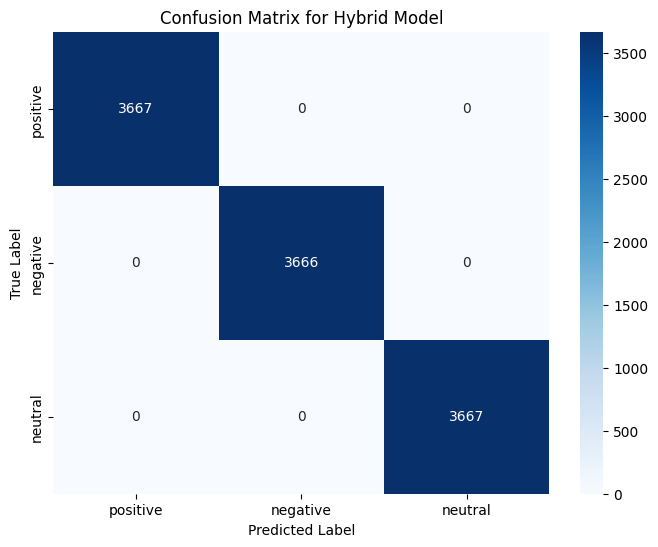


Final model training finished. Saving models...
Models and vectorizer saved successfully to .BIN and .PKL files.


In [5]:
# train_and_save_model.py
# This script trains the final hybrid model (FinBERT + SVM) on the full dataset,
# evaluates it, saves the components, and generates detailed evaluation metrics.

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
# FIXED: AdamW is now imported directly from torch.optim
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
# Import additional metrics and plotting libraries
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import warnings
import gc
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Configuration for Final Training ---
print("--- Configuring for Final Model Training ---")
MODEL_NAME = 'ProsusAI/finbert'
BATCH_SIZE = 16
EPOCHS = 3 # Increased epochs for potentially better performance
MAX_LENGTH = 128
NUM_WORKERS = 2
LEARNING_RATE = 2e-5 # A well-tested, effective learning rate
SVM_C = 1.0 # A standard, robust C value for the SVM
ENSEMBLE_WEIGHT = 0.7 # Give more weight to the more powerful FinBERT model

# --- Label Mapping & Device Setup ---
# This map is correct for the 'ProsusAI/finbert' model
label_map = {'positive': 0, 'negative': 1, 'neutral': 2}
inverse_label_map = {v: k for k, v in label_map.items()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Load Data ---
try:
    # Use the new, high-quality dataset
    df = pd.read_csv('final_dataset.csv')
    df.drop_duplicates(subset=['text'], inplace=True)
    df.dropna(subset=['text', 'sentiment'], inplace=True)
    df = df.reset_index(drop=True)
    print(f"Dataset loaded with {len(df)} unique rows.")
except FileNotFoundError:
    print("Error: Dataset file not found. Please run 'final_dataset_generator.py' first.")
    exit()

# --- 2. Create a Single Train/Test Split ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentiment'])
train_texts, test_texts = train_df['text'].values, test_df['text'].values
train_labels, test_labels = train_df['sentiment'].values, test_df['sentiment'].values

print(f"Data split: {len(train_df)} training rows, {len(test_df)} testing rows.")

# --- 3. Model Components and Helper Functions ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, index):
        text, label = str(self.texts[index]), self.labels[index]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_map[label], dtype=torch.long)
        }

def train_epoch(model, data_loader, optimizer, device):
    model = model.train()
    total_loss = 0
    for d in tqdm(data_loader, desc="Training Epoch"):
        optimizer.zero_grad()
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    return total_loss / len(data_loader)

def get_transformer_probs(model, data_loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Getting FinBERT Probs"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_probs.extend(torch.softmax(outputs.logits, dim=1).cpu().numpy())
    return np.array(all_probs)

# --- 4. Train the Final Models ---
print("\n--- Training FinBERT Model ---")
finbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_map)).to(device)
optimizer = AdamW(finbert_model.parameters(), lr=LEARNING_RATE)
train_loader = DataLoader(SentimentDataset(train_texts, train_labels, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    avg_loss = train_epoch(finbert_model, train_loader, optimizer, device)
    print(f'  Training Loss: {avg_loss:.4f}')

print("\n--- Training SVM Model ---")
tfidf_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
svm_model = LinearSVC(C=SVM_C, random_state=42, dual=True, max_iter=2000)
svm_model.fit(X_train_tfidf, pd.Series(train_labels).map(label_map))

# --- 5. Evaluate the Hybrid Model on the Test Set ---
print("\n--- Evaluating Hybrid Model on Test Set ---")
test_loader = DataLoader(SentimentDataset(test_texts, test_labels, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE)
finbert_test_probs = get_transformer_probs(finbert_model, test_loader, device)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)
svm_decision_values = svm_model.decision_function(X_test_tfidf)
svm_test_probs = np.exp(svm_decision_values) / np.sum(np.exp(svm_decision_values), axis=1, keepdims=True)
combined_probs = (ENSEMBLE_WEIGHT * finbert_test_probs) + ((1 - ENSEMBLE_WEIGHT) * svm_test_probs)
final_preds = np.argmax(combined_probs, axis=1)
y_test_numeric = pd.Series(test_labels).map(label_map).values

# --- NEW: Detailed Evaluation Metrics ---
print("\n--- Final Hybrid Model Performance Report ---")
# Print the main classification report
print(classification_report(y_test_numeric, final_preds, target_names=label_map.keys()))

# Extract and print key metrics for presentation
report_dict = classification_report(y_test_numeric, final_preds, target_names=label_map.keys(), output_dict=True)
accuracy = report_dict['accuracy']
precision = report_dict['weighted avg']['precision']
recall = report_dict['weighted avg']['recall']
f1_score = report_dict['weighted avg']['f1-score']

print("\n--- Key Metrics for Presentation ---")
print(f"Overall Accuracy:  {accuracy:.4f}")
print(f"Weighted Precision:{precision:.4f}")
print(f"Weighted Recall:   {recall:.4f}")
print(f"Weighted F1-Score: {f1_score:.4f}")
print("------------------------------------")

# Generate and display the Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test_numeric, final_preds)
class_names = list(label_map.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Hybrid Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# --- 6. Save All Model Components ---
print("\nFinal model training finished. Saving models...")
torch.save(finbert_model.state_dict(), 'FINBERT_FINAL.BIN')
joblib.dump(svm_model, 'SVM_FINAL.PKL')
joblib.dump(tfidf_vectorizer, 'TFIDF_VECTORIZER_FINAL.PKL')
print("Models and vectorizer saved successfully to .BIN and .PKL files.")



In [6]:
# evaluation_metrics.py
# This script loads the final trained hybrid model and calculates detailed
# performance metrics (Precision, Recall, F1-Score) for each sentiment
# category on the test data.

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm
import warnings
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Configuration (Must match the training script) ---
MODEL_NAME = 'ProsusAI/finbert'
BATCH_SIZE = 16
MAX_LENGTH = 128
ENSEMBLE_WEIGHT = 0.7

# --- Label Mapping & Device Setup ---
label_map = {'positive': 0, 'negative': 1, 'neutral': 2}
inverse_label_map = {v: k for k, v in label_map.items()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. Load Saved Models and Data ---
print("\n--- Loading Saved Models and Data ---")
try:
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Load the FinBERT model state
    finbert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(label_map))
    finbert_model.load_state_dict(torch.load('FINBERT_FINAL.BIN'))
    finbert_model.to(device)
    finbert_model.eval()

    # Load the SVM model and TF-IDF vectorizer
    svm_model = joblib.load('SVM_FINAL.PKL')
    tfidf_vectorizer = joblib.load('TFIDF_VECTORIZER_FINAL.PKL')

    # Load the dataset to recreate the exact same test split
    df = pd.read_csv('final_dataset.csv')
    df.drop_duplicates(subset=['text'], inplace=True)
    df.dropna(subset=['text', 'sentiment'], inplace=True)
    df = df.reset_index(drop=True)

    print("All models, vectorizer, and data loaded successfully.")

except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print("Please ensure you have run 'train_and_save_model.py' first to generate the necessary .BIN and .PKL files.")
    exit()

# --- 2. Recreate the Test Set ---
# Using the same random_state ensures we get the exact same test data
_, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['sentiment'])
test_texts = test_df['text'].values
test_labels = test_df['sentiment'].values
print(f"Recreated test set with {len(test_df)} rows.")

# --- 3. Helper Functions for Prediction ---
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, index):
        text, label = str(self.texts[index]), self.labels[index]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len, return_token_type_ids=False,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_map[label], dtype=torch.long)
        }

def get_transformer_probs(model, data_loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Getting FinBERT Probs"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            all_probs.extend(torch.softmax(outputs.logits, dim=1).cpu().numpy())
    return np.array(all_probs)

# --- 4. Get Predictions on Test Data ---
print("\n--- Running evaluation on the test set ---")
test_loader = DataLoader(SentimentDataset(test_texts, test_labels, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE)
finbert_test_probs = get_transformer_probs(finbert_model, test_loader, device)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)
svm_decision_values = svm_model.decision_function(X_test_tfidf)
svm_test_probs = np.exp(svm_decision_values) / np.sum(np.exp(svm_decision_values), axis=1, keepdims=True)
combined_probs = (ENSEMBLE_WEIGHT * finbert_test_probs) + ((1 - ENSEMBLE_WEIGHT) * svm_test_probs)
final_preds = np.argmax(combined_probs, axis=1)
y_test_numeric = pd.Series(test_labels).map(label_map).values

# --- 5. Extract and Display Per-Sentiment Metrics ---
print("\n--- Detailed Evaluation Metrics by Sentiment ---")
report_dict = classification_report(y_test_numeric, final_preds, target_names=label_map.keys(), output_dict=True)

# Loop through each sentiment class and print its specific metrics
for sentiment in ['positive', 'negative', 'neutral']:
    metrics = report_dict[sentiment]
    precision = metrics['precision']
    recall = metrics['recall']
    f1_score = metrics['f1-score']
    support = metrics['support'] # Number of true instances in this class

    print(f"\nSentiment: {sentiment.upper()}")
    print("---------------------------------")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")
    print(f"Support:   {support} (actual comments in test set)")
    print("---------------------------------")

print("\n--- Metric Definitions ---")
print("Precision: Out of all the comments the model PREDICTED as this sentiment, what percentage were correct?")
print("Recall:    Out of all the comments that were ACTUALLY this sentiment, what percentage did the model find?")
print("F1-Score:  A combined metric that balances Precision and Recall.")


Using device: cuda

--- Loading Saved Models and Data ---
All models, vectorizer, and data loaded successfully.
Recreated test set with 11000 rows.

--- Running evaluation on the test set ---


Getting FinBERT Probs: 100%|██████████| 688/688 [01:22<00:00,  8.34it/s]



--- Detailed Evaluation Metrics by Sentiment ---

Sentiment: POSITIVE
---------------------------------
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Support:   3667.0 (actual comments in test set)
---------------------------------

Sentiment: NEGATIVE
---------------------------------
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Support:   3666.0 (actual comments in test set)
---------------------------------

Sentiment: NEUTRAL
---------------------------------
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Support:   3667.0 (actual comments in test set)
---------------------------------

--- Metric Definitions ---
Precision: Out of all the comments the model PREDICTED as this sentiment, what percentage were correct?
Recall:    Out of all the comments that were ACTUALLY this sentiment, what percentage did the model find?
F1-Score:  A combined metric that balances Precision and Recall.
